# Практикалық жұмыс: Деректерді зерттеу (EDA) және Feature Engineering


**Датасет:** IBM HR Employee Attrition (1470 жазба, 35 баған)

**Нұсқаулық:**
- Әр тапсырмадағы `#TODO` белгісі бар жерлерге код жазыңыз
- Әр тапсырма шамамен 10 минутқа есептелген
- Қажет болса, тапсырма ішіндегі комментарийлерге назар аударыңыз

## Деректерді жүктеу

Алдымен қажетті кітапханаларды импорттап, датасетті GitHub сілтемесі арқылы жүктейміз.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

url = "https://raw.githubusercontent.com/nelson-wu/employee-attrition-ml/master/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(url)
print("Датасет сәтті жүктелді!")
print(f"Жолдар саны: {df.shape[0]}, Бағандар саны: {df.shape[1]}")
df.head()

Датасет сәтті жүктелді!
Жолдар саны: 1470, Бағандар саны: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 1-Бөлім. Деректерді зерттеу (Exploratory Data Analysis)

**Мақсат:** Датасеттің құрылымын, типтерін, негізгі статистикалық сипаттамаларын тусіну және алғашқы талдау жасау.

**Қолданылатын негізгі функциялар:**

| Функция | Сипаттамасы |
|---------|-------------|
| `df.shape` | Жолдар мен бағандар санын қайтарады |
| `df.info()` | Әр бағанның типі мен бос мәндер саны |
| `df.describe()` | Сандық бағандардың статистикасы (орта, медиана, т.б.) |
| `df.dtypes` | Әр бағанның деректер типі |
| `df.nunique()` | Әр бағандағы бірегей мәндер саны |
| `df.value_counts()` | Мәндердің жиілік кестесі |
| `df.select_dtypes()` | Типі бойынша бағандарды сурыптау |
| `df.columns` | Барлық баған аттарының тізімі |
| `df.isnull().sum()` | Бос мәндер санын есептеу |
| `df.duplicated().sum()` | Қайталанатын жолдар саны |

### 1.1-тапсырма. Датасеттің жалпы құрылымын қарау

`df.shape`, `df.columns` және `df.dtypes` арқылы датасетте қанша жол, баған бар екенін және олардың типтерін анықтаңыз.

In [57]:
# TODO: Датасеттің жолдар мен бағандар санын шығарыңыз
# Кеңес: df.shape қолданыңыз
print("Жолдар саны:", )
print("Бағандар саны:", )
print(df.shape)
print(df.columns)
print(df.dtypes)

Жолдар саны:
Бағандар саны:
(1470, 35)
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
Educa

In [58]:
# TODO: Барлық баған аттарын тізім ретінде шығарыңыз
# Кеңес: df.columns қолданыңыз




In [59]:
# TODO: Әр бағанның деректер типін шығарыңыз
# Кеңес: df.dtypes қолданыңыз


### 1.2-тапсырма. df.info() арқылы толық ақпарат алу

`df.info()` функциясы бағандардың типтерін, бос мандердің бар-жоғын және жадты корсетеді.

In [60]:
# TODO: df.info() арқылы датасеттің толық ақпаратын шығарыңыз
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### 1.3-тапсырма. Сандық бағандардың статистикасы

`df.describe()` орта мән, стандартты ауытқу, минимум, максимум, квартильдерді корсетеді.

In [61]:
# TODO: Сандық бағандардың статистикалық сипаттамасын шығарыңыз
# Кеңес: df.describe() қолданыңыз
print(df.describe([0]))


               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
0%       18.000000   102.000000          1.000000     1.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335                 1.093082    20.329428        0.711561   
min          1.000000              

### 1.4-тапсырма. Санаттық бағандардың статистикасы

`df.describe(include='object')` тек мәтіндік (санаттық) бағандардың статистикасын корсетеді.

In [62]:
# TODO: Тек санаттық (object) бағандардың статистикасын шығарыңыз
# Кеңес: df.describe(include='object') қолданыңыз

print(df.describe(include='object'))


       Attrition BusinessTravel              Department EducationField Gender  \
count       1470           1470                    1470           1470   1470   
unique         2              3                       3              6      2   
top           No  Travel_Rarely  Research & Development  Life Sciences   Male   
freq        1233           1043                     961            606    882   

                JobRole MaritalStatus Over18 OverTime  
count              1470          1470   1470     1470  
unique                9             3      1        2  
top     Sales Executive       Married      Y       No  
freq                326           673   1470     1054  


### 1.5-тапсырма. Бірегей мәндер санын анықтау

`df.nunique()` әр бағандағы бірегей мандердің санын корсетеді. Бұл санаттық және сандық бағандарды ажыратуға комектеседі.

In [63]:
# TODO: Әр бағандағы бірегей мәндер санын шығарыңыз
# Кеңес: df.nunique() қолданыңыз
print(df.nunique() )


Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

### 1.6-тапсырма. Мақсатты айнымалының (Attrition) таралуы

`value_counts()` арқылы Attrition бағанындағы мандердің жиілігін анықтаңыз.

In [64]:
# TODO: Attrition бағанының мәндер таралуын шығарыңыз
# Кеңес: df['Attrition'].value_counts() қолданыңыз
print("Абсолюттік мән:")
print(df['Attrition'].value_counts())

print("\nПайыздық мән:")
# Кеңес: value_counts(normalize=True) қолданыңыз


Абсолюттік мән:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Пайыздық мән:


### 1.7-тапсырма. Сандық және санаттық бағандарды бөлу

`select_dtypes()` арқылы бағандарды типі бойынша бөліп, олардың тізімін жасаңыз.

In [65]:
# TODO: Сандық бағандар тізімін алыңыз
# Кеңес: df.select_dtypes(include='number').columns.tolist()
numeric_cols =
print(f"Сандық бағандар саны: {len(numeric_cols)}")
print(numeric_cols)

# TODO: Санаттық бағандар тізімін алыңыз
# Кеңес: df.select_dtypes(include='object').columns.tolist()
categorical_cols =
print(f"\nСанаттық бағандар саны: {len(categorical_cols)}")
print(categorical_cols)

SyntaxError: invalid syntax (2205106119.py, line 3)

### 1.8-тапсырма. Бос мандерді тексеру

`isnull().sum()` арқылы әр бағанда бос мандердің бар-жоғын тексеріңіз.

In [66]:
# TODO: Әр бағандағы бос мәндер санын шығарыңыз
# Кеңес: df.isnull().sum() қолданыңыз

# TODO: Жалпы бос мәндер санын шығарыңыз
print("\nЖалпы бос мәндер саны:", )


Жалпы бос мәндер саны:


### 1.9-тапсырма. Қайталанатын жолдарды тексеру

`duplicated()` арқылы датасетте қайталанатын жолдардың бар-жоғын анықтаңыз.

In [67]:
# TODO: Қайталанатын жолдар санын анықтаңыз
# Кеңес: df.duplicated().sum() қолданыңыз
print("Қайталанатын жолдар саны:", )

Қайталанатын жолдар саны:


### 1.10-тапсырма. Корреляция матрицасы

Сандық бағандар арасындағы корреляцияны есептеп, ең жоғары корреляциясы бар 5 жұпты табыңыз.

In [68]:
# TODO: Корреляция матрицасын есептеңіз
# Кеңес: df[numeric_cols].corr() қолданыңыз
corr_matrix =

# TODO: Ең жоғары корреляциясы бар 5 жұпты табыңыз
# Кеңес: corr_matrix.unstack() арқылы сериясына айналдырыңыз,
# содан кейін sort_values(ascending=False) арқылы сұрыптаңыз
# Диагональді (1.0) алып тастаңыз
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]
# TODO: Ең жоғары 5 жұпты шығарыңыз
print("Ең жоғары корреляция жұптары:")


SyntaxError: invalid syntax (437973778.py, line 3)

## 2-Бөлім. Matplotlib және Seaborn визуализациясы

**Мақсат:** Деректерді графиктер арқылы визуалды түрде талдау: таралуды, байланысты, ауытқуларды, санаттар бойынша салыстыруды корсету.

**Қолданылатын негізгі функциялар:**

| Функция | Сипаттамасы |
|---------|-------------|
| `plt.hist()` / `sns.histplot()` | Гистограмма (таралу) |
| `plt.scatter()` / `sns.scatterplot()` | Нуктелік диаграмма |
| `sns.boxplot()` | Boxplot (ауытқуларды көру) |
| `sns.heatmap()` | Жылу картасы (корреляция) |
| `sns.countplot()` | Санаттық мәндердің жиілік диаграммасы |
| `sns.barplot()` | Орта мәндерді салыстыру |
| `sns.pairplot()` | Жұптық графиктер |
| `plt.subplots()` | Бірнеше график бір суретте |
| `plt.xlabel()`, `plt.ylabel()` | Ось белгілері |
| `plt.title()` | График тақырыбы |

### 2.1-тапсырма. Жас (Age) бағанының гистограммасы

`sns.histplot()` арқылы жас таралуын визуализациялаңыз. `kde=True` параметрі тегістелген қисық сызады.

In [ ]:
# TODO: Age бағанының гистограммасын сызыңыз
# Кеңес: sns.histplot(df['Age'], kde=True, bins=20)
plt.figure(figsize=(8, 5))

plt.title('Қызметкерлердің жас таралуы')
plt.xlabel('Жас')
plt.ylabel('Жиілік')
plt.show()

### 2.2-тапсырма. Атрибуция бойынша жалақы салыстыруы (Boxplot)

`sns.boxplot()` арқылы Attrition тобы бойынша MonthlyIncome таралуын салыстырыңыз.

In [ ]:
# TODO: Attrition бойынша MonthlyIncome boxplot сызыңыз
# Кеңес: sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.figure(figsize=(8, 5))

plt.title('Атрибуция бойынша айлық жалақы таралуы')
plt.xlabel('Атрибуция')
plt.ylabel('Айлық жалақы')
plt.show()

### 2.3-тапсырма. Нуктелік диаграмма (Scatter plot)

`sns.scatterplot()` арқылы Age мен MonthlyIncome арасындағы байланысты корсетіңіз. Attrition бойынша түске бөліңіз.

In [ ]:
# TODO: Age мен MonthlyIncome арасындағы scatter plot сызыңыз
# Кеңес: sns.scatterplot(x='Age', y='MonthlyIncome', hue='Attrition', data=df, alpha=0.6)
plt.figure(figsize=(10, 6))

plt.title('Жас пен айлық жалақы арасындағы байланыс')
plt.xlabel('Жас')
plt.ylabel('Айлық жалақы')
plt.show()

### 2.4-тапсырма. Корреляция жылу картасы (Heatmap)

`sns.heatmap()` арқылы сандық бағандар арасындағы корреляцияны визуализациялаңыз. `annot=True` мандерді корсетеді.

In [ ]:
# TODO: Таңдаулы сандық бағандар арасындағы корреляция heatmap сызыңыз
# Кеңес: Алдымен бағандар тізімін жасаңыз, содан кейін sns.heatmap()
selected_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
                 'YearsAtCompany', 'YearsInCurrentRole',
                 'DistanceFromHome', 'DailyRate']

plt.figure(figsize=(10, 8))
# TODO: sns.heatmap() арқылы корреляция картасын сызыңыз
# Кеңес: sns.heatmap(df[selected_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Сандық бағандар корреляциясы')
plt.tight_layout()
plt.show()

### 2.5-тапсырма. Санаттық мандердің жиілік диаграммасы (Countplot)

`sns.countplot()` арқылы Department бағанындағы мандердің жиілігін корсетіңіз.

In [ ]:
# TODO: Department бағанының countplot сызыңыз
# Кеңес: sns.countplot(x='Department', hue='Attrition', data=df)
plt.figure(figsize=(8, 5))

plt.title('Департамент бойынша қызметкерлер саны')
plt.xlabel('Департамент')
plt.ylabel('Саны')
plt.show()

### 2.6-тапсырма. Бірнеше бағанның boxplot графигі

`plt.subplots()` арқылы бірнеше сандық бағанның boxplot графигін бір суретте корсетіңіз.

In [ ]:
# TODO: 4 сандық бағанның boxplot графиктерін бір суретте сызыңыз
# Кеңес: fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols_to_plot = ['MonthlyIncome', 'Age', 'TotalWorkingYears', 'YearsAtCompany']

for i, col in enumerate(cols_to_plot):
    ax = axes[i // 2, i % 2]
    # TODO: sns.boxplot(y=df[col], ax=ax) арқылы сызыңыз

    ax.set_title(col)

plt.tight_layout()
plt.show()

### 2.7-тапсырма. Орта жалақыны лауазым бойынша салыстыру (Barplot)

`sns.barplot()` арқылы JobRole бойынша орта MonthlyIncome мәнін корсетіңіз.

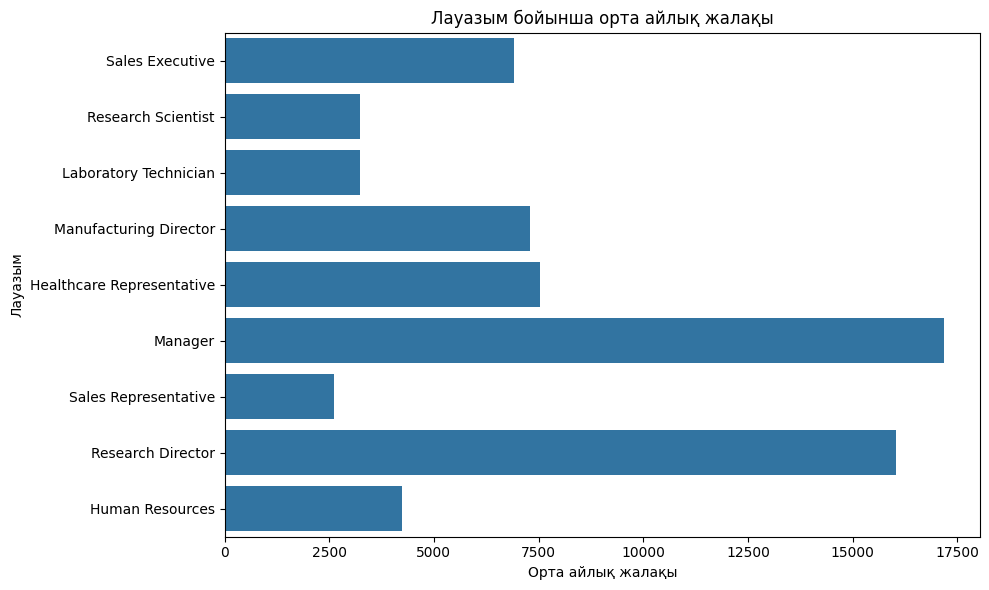

In [70]:
# TODO: JobRole бойынша орта MonthlyIncome barplot сызыңыз
# Кеңес: sns.barplot(x='MonthlyIncome', y='JobRole', data=df, ci=None)
plt.figure(figsize=(10, 6))
sns.barplot(x='MonthlyIncome',y='JobRole',data=df, ci=None)
plt.title('Лауазым бойынша орта айлық жалақы')
plt.xlabel('Орта айлық жалақы')
plt.ylabel('Лауазым')
plt.tight_layout()
plt.show()

### 2.8-тапсырма. Бірнеше бағанның гистограммалары

`plt.subplots()` арқылы бірнеше сандық бағанның гистограммаларын сызыңыз.

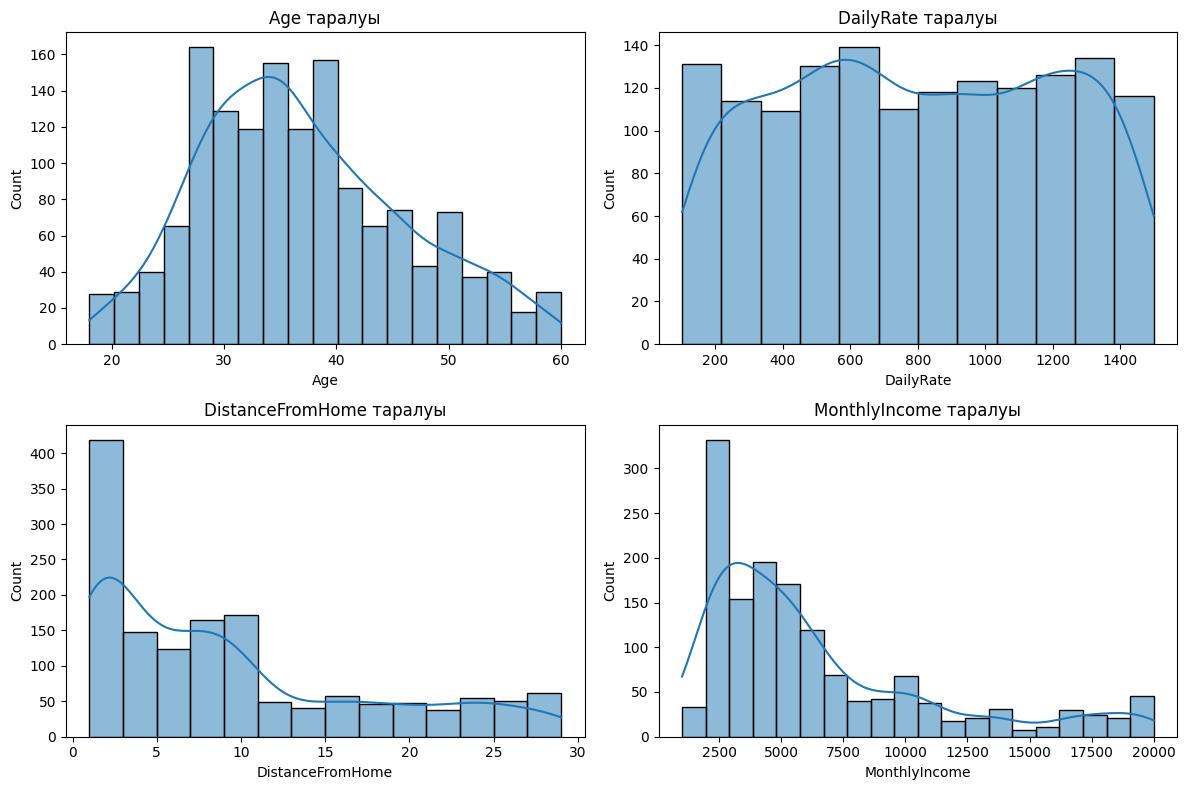

In [103]:
# TODO: 4 сандық бағанның гистограммаларын бір суретте сызыңыз
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols_to_plot = ['Age', 'DailyRate', 'DistanceFromHome', 'MonthlyIncome']

for i, col in enumerate(cols_to_plot):
    ax = axes[i // 2, i % 2]
    # TODO: sns.histplot(df[col], kde=True, ax=ax) арқылы сызыңыз
    sns.histplot(df[col],kde=True ,ax=ax)
    ax.set_title(f'{col} таралуы')

plt.tight_layout()
plt.show()

### 2.9-тапсырма. Pie chart (дөңгелек диаграмма)

Matplotlib `plt.pie()` арқылы Attrition бағанының пайыздық таралуын корсетіңіз.

In [ ]:
# TODO: Attrition бағанының pie chart сызыңыз
# Кеңес: df['Attrition'].value_counts() мәндерін қолданыңыз
plt.figure(figsize=(6, 6))
attrition_counts = df['Attrition'].value_counts()

# TODO: plt.pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%') сызыңыз

plt.title('Атрибуция таралуы')
plt.show()

### 2.10-тапсырма. OverTime бойынша Attrition визуализациясы

OverTime (артық жумыс) мен Attrition арасындағы байланысты корсетіңіз.

In [ ]:
# TODO: OverTime бойынша Attrition countplot сызыңыз
# Кеңес: sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.figure(figsize=(8, 5))

plt.title('Артық жұмыс пен атрибуция арасындағы байланыс')
plt.xlabel('Артық жұмыс')
plt.ylabel('Қызметкерлер саны')
plt.show()

## 3-Болім. Деректерді тазарту және бос мандерді ондеу

**Мақсат:** Датасетте бос мандерді, қайталанатын жолдарды, қажетсіз бағандарды анықтап ондеу. Бос мандерді толтыру стратегияларын қолдану.

**Қолданылатын негізгі функциялар:**

| Функция | Сипаттамасы |
|---------|-------------|
| `df.drop()` | Бағандарды немесе жолдарды жою |
| `df.dropna()` | Бос мәндері бар жолдарды жою |
| `df.fillna()` | Бос мәндерді толтыру (орта, медиана, мода) |
| `df.replace()` | Мәндерді ауыстыру |
| `df.copy()` | Датафреймнің көшірмесін жасау |
| `df.rename()` | Бағандарды қайта атау |
| `df.astype()` | Деректер типін өзгерту |
| `df.isnull()` | Бос мәндерді тексеру |
| `np.random.choice()` | Кездейсоқ мәндер орнату (NaN жасау) |
| `df.interpolate()` | Интерполяция арқылы толтыру |

Ескерту: Бұл датасетте бос мандер жоқ болуы мумкін. Сондықтан алдымен жасанды бос мандер қосамыз, содан кейін оларды ондеу тәсілдерін уйренеміз.

### 3.1-тапсырма. Жумыс копиясын жасау және қажетсіз бағандарды жою

`df.copy()` арқылы жаңа копия жасаңыз. `EmployeeCount`, `Over18`, `StandardHours` бағандары барлық жолда бірдей мәнге ие, сондықтан оларды жойыңыз.

In [72]:
# TODO: Датафреймнің көшірмесін жасаңыз
# Кеңес: df_clean = df.copy()
df_clean =df.copy()

# TODO: Қажетсіз бағандарды жойыңыз
# Кеңес: df_clean.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], inplace=True)

print(f"Бағандар саны (бұрын): {df.shape[1]}")
print(f"Бағандар саны (кейін): {df_clean.shape[1]}")

Бағандар саны (бұрын): 35
Бағандар саны (кейін): 35


### 3.2-тапсырма. Жасанды бос мандерді қосу

Жаттығу ушін Age, MonthlyIncome, DistanceFromHome бағандарына кездейсоқ бос мандер қосамыз.

In [75]:
np.random.seed(42)

# TODO: Age бағанында 50 кездейсоқ жолға NaN қосыңыз
# Кеңес: idx = np.random.choice(df_clean.index, size=50, replace=False)
#        df_clean.loc[idx, 'Age'] = np.nan
idx_age = np.random.choice(df_clean.index, size=50, replace=False)


# TODO: MonthlyIncome бағанында 40 кездейсоқ жолға NaN қосыңыз
idx_income = np.random.choice(df_clean.index, size=40, replace=False)


# TODO: DistanceFromHome бағанында 30 кездейсоқ жолға NaN қосыңыз
idx_dist = np.random.choice(df_clean.index, size=30, replace=False)


# Бос мәндерді тексеру
print("Бос мәндер:")
print(df_clean[['Age', 'MonthlyIncome', 'DistanceFromHome']].isnull().sum())

Бос мәндер:
Age                 0
MonthlyIncome       0
DistanceFromHome    0
dtype: int64


### 3.3-тапсырма. Бос мандерді визуализациялау

Бос мандердің қай бағандарда бар екенін барлық график арқылы корсетіңіз.

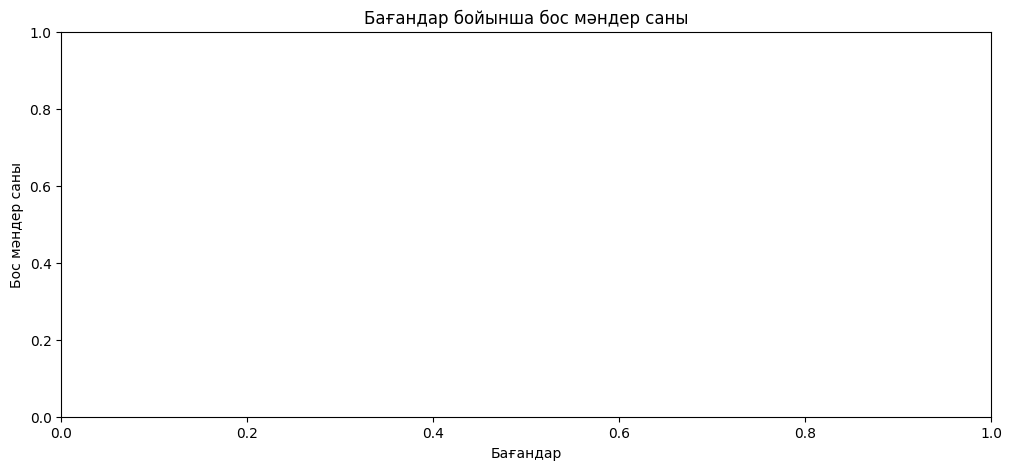

In [74]:
# TODO: Бос мәндерді бар графикпен визуализациялаңыз
# Кеңес: df_clean.isnull().sum() арқылы мәндерді алып, bar plot сызыңыз
plt.figure(figsize=(12, 5))
missing = df_clean.isnull().sum()
missing = missing[missing > 0]

# TODO: missing.plot(kind='bar') арқылы сызыңыз

plt.title('Бағандар бойынша бос мәндер саны')
plt.xlabel('Бағандар')
plt.ylabel('Бос мәндер саны')
plt.show()

### 3.4-тапсырма. Бос мандерді орта мәнмен толтыру (mean)

Age бағанындағы бос мандерді орта мәнмен толтырыңыз.

In [77]:
# TODO: Age бағанының орта мәнін есептеңіз
# Кеңес: df_clean['Age'].mean()
age_mean =df_clean['Age'].mean()
print(f"Age бағанының орта мәні: {age_mean:.2f}")

# TODO: Бос мәндерді орта мәнмен толтырыңыз
# Кеңес: df_clean['Age'].fillna(age_mean, inplace=True)

print(f"Age бос мәндер (толтырудан кейін): {df_clean['Age'].isnull().sum()}")

Age бағанының орта мәні: 36.92
Age бос мәндер (толтырудан кейін): 0


### 3.5-тапсырма. Бос мандерді медианамен толтыру

MonthlyIncome бағанында ауытқулар болуы мумкін, сондықтан медиана қолдану дұрысырақ.

In [79]:
# TODO: MonthlyIncome бағанының медианасын есептеңіз
# Кеңес: df_clean['MonthlyIncome'].median()
income_median =df_clean['MonthlyIncome'].median()
print(f"MonthlyIncome медианасы: {income_median:.2f}")

# TODO: Бос мәндерді медианамен толтырыңыз
# Кеңес: df_clean['MonthlyIncome'].fillna(income_median, inplace=True)

print(f"MonthlyIncome бос мәндер (кейін): {df_clean['MonthlyIncome'].isnull().sum()}")

MonthlyIncome медианасы: 4919.00
MonthlyIncome бос мәндер (кейін): 0


### 3.6-тапсырма. Бос мандерді модамен толтыру

DistanceFromHome бағанын ең жиі кездесетін мәнмен (мода) толтырыңыз.

In [80]:
# TODO: DistanceFromHome бағанының модасын табыңыз
# Кеңес: df_clean['DistanceFromHome'].mode()[0]
dist_mode =df_clean['DistanceFromHome'].mode()[0]
print(f"DistanceFromHome модасы: {dist_mode}")

# TODO: Бос мәндерді модамен толтырыңыз

print(f"DistanceFromHome бос мәндер (кейін): {df_clean['DistanceFromHome'].isnull().sum()}")

DistanceFromHome модасы: 2
DistanceFromHome бос мәндер (кейін): 0


### 3.7-тапсырма. Қайталанатын жолдарды жою

Датасетте қайталанатын жолдар бар-жоғын тексеріп, бар болса жойыңыз.

In [83]:
# TODO: Қайталанатын жолдар санын тексеріңіз
# Кеңес: df_clean.duplicated().sum()
print("Қайталанатын жолдар (бұрын):",df_clean.duplicated().sum())


# TODO: Қайталанатын жолдарды жойыңыз (егер бар болса)
# Кеңес: df_clean.drop_duplicates(inplace=True)

print("Қайталанатын жолдар (кейін):", df_clean.drop_duplicates(inplace=True))
print(f"Қалған жолдар саны: {df_clean.shape[0]}")

Қайталанатын жолдар (бұрын): 0
Қайталанатын жолдар (кейін): None
Қалған жолдар саны: 1470


### 3.8-тапсырма. Деректер типін озгерту

Кейбір сандық бағандар шын мәнінде санаттық (мысалы, Education, JobLevel). Оларды тусінікті мандерге ауыстырыңыз.

In [88]:
# TODO: Education бағанын мәтіндік мәндерге ауыстырыңыз
# Кеңес: df_clean['Education'].replace({...}) арқылы
education_map = {
    1: 'Below College',
    2: 'College',
    3: 'Bachelor',
    4: 'Master',
    5: 'Doctor'
}
# TODO: replace() арқылы ауыстырыңыз
df_clean['Education']=df_clean['Education'].replace(education_map)
print("Education бағанының бірегей мәндері:")
print(df_clean['Education'].value_counts())

Education бағанының бірегей мәндері:
Education
Bachelor         572
Master           398
College          282
Below College    170
Doctor            48
Name: count, dtype: int64


### 3.9-тапсырма. Бағандарды қайта атау

`rename()` арқылы бағандарды тусінікті атауларға озгертіңіз.

In [ ]:
# TODO: Бірнеше бағанды қайта атаңыз
# Кеңес: df_clean.rename(columns={'MonthlyIncome': 'AylykZhalaky', ...}, inplace=True)
df_clean.rename(columns={
    'MonthlyIncome': 'AylykZhalaky',
    'YearsAtCompany': 'KompaniadagyZhyldar'
}, inplace=True)

# Тексеру
print("Жаңа баған аттары (бірнешеуі):")
print(df_clean.columns.tolist()[:10])

### 3.10-тапсырма. Тазартылған датасеттің қорытынды тексеруі

Барлық тазарту қадамдарынан кейін датасеттің жай-кұйін тексеріңіз.

In [ ]:
# TODO: Тазартылған датасеттің ақпаратын шығарыңыз
print("Жолдар:", df_clean.shape[0])
print("Бағандар:", df_clean.shape[1])
print("\nБос мәндер:")
# TODO: df_clean.isnull().sum().sum() қолданыңыз
print("Жалпы бос мәндер:", )

# Баған аттарын бастапқы қалпына қайтарамыз (келесі бөлімдер үшін)
df_clean.rename(columns={
    'AylykZhalaky': 'MonthlyIncome',
    'KompaniadagyZhyldar': 'YearsAtCompany'
}, inplace=True)
print("\nДатасет тазартылды!")

## 4-Болім. Ауытқуларды (Outliers) анықтау және ондеу

**Мақсат:** Деректердегі ауытқуларды IQR және Z-score әдістерімен анықтап, оларды ондеу тәсілдерін уйрену.

**Қолданылатын негізгі функциялар:**

| Функция | Сипаттамасы |
|---------|-------------|
| `df.quantile()` | Квартильдерді есептеу (Q1, Q3) |
| `IQR` формуласы | Q3 - Q1, ауытқу шекарасы |
| `scipy.stats.zscore()` | Z-score есептеу |
| `np.abs()` | Абсолютті мән |
| `sns.boxplot()` | Boxplot арқылы ауытқуларды көру |
| `df.clip()` | Мәндерді белгілі шекараға қысу |
| `np.where()` | Шартты ауыстыру |
| `np.log1p()` | Логарифмдік түрлендіру |
| `df.loc[]` | Жолдарды шарт бойынша таңдау |
| `plt.subplots()` | Бірнеше график салу |

### 4.1-тапсырма. IQR әдісі: формуланы тусіну

IQR (Interquartile Range) формуласын қолданып MonthlyIncome бағанының шекараларын есептеңіз.

In [ ]:
# TODO: Q1 (25-ші перцентиль) және Q3 (75-ші перцентиль) есептеңіз
# Кеңес: Q1 = df_clean['MonthlyIncome'].quantile(0.25)
Q1 =
Q3 =

# TODO: IQR есептеңіз
IQR =

# TODO: Төменгі және жоғарғы шекараны есептеңіз
# Кеңес: lower = Q1 - 1.5 * IQR, upper = Q3 + 1.5 * IQR
lower_bound =
upper_bound =

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Төменгі шекара: {lower_bound}")
print(f"Жоғарғы шекара: {upper_bound}")

### 4.2-тапсырма. IQR арқылы ауытқуларды анықтау

IQR шекараларынан тыс жатқан мандерді анықтаңыз.

In [ ]:
# TODO: Ауытқулар санын анықтаңыз
# Кеңес: (df_clean['MonthlyIncome'] < lower_bound) | (df_clean['MonthlyIncome'] > upper_bound)
outliers_mask =
outlier_count = outliers_mask.sum()

print(f"MonthlyIncome бағанындағы ауытқулар саны: {outlier_count}")
print(f"Жалпы жолдар: {len(df_clean)}")
print(f"Ауытқулар пайызы: {outlier_count / len(df_clean) * 100:.2f}%")

### 4.3-тапсырма. Z-score әдісі

`scipy.stats.zscore()` арқылы Z-score есептеп, абсолютті мәні 3-тен жоғары мандерді ауытқу ретінде анықтаңыз.

In [ ]:
from scipy import stats

# TODO: MonthlyIncome бағанының Z-score есептеңіз
# Кеңес: z_scores = np.abs(stats.zscore(df_clean['MonthlyIncome']))
z_scores =

# TODO: Z-score > 3 болатын ауытқулар санын анықтаңыз
outliers_zscore =
print(f"Z-score әдісімен табылған ауытқулар: {outliers_zscore}")

### 4.4-тапсырма. Ауытқуларды визуализациялау (бұрын/кейін)

Boxplot арқылы ауытқуларды корсетіңіз.

In [ ]:
# TODO: MonthlyIncome бағанының boxplot графигін сызыңыз
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Бұрынғы boxplot
# TODO: sns.boxplot(y=df_clean['MonthlyIncome'], ax=axes[0])
axes[0].set_title('MonthlyIncome (бұрын)')

# Histogram
# TODO: sns.histplot(df_clean['MonthlyIncome'], kde=True, ax=axes[1])
axes[1].set_title('MonthlyIncome таралуы')

plt.tight_layout()
plt.show()

### 4.5-тапсырма. Ауытқуларды шекарамен шектеу (Capping/Clipping)

`df.clip()` арқылы мандерді IQR шекараларына шектеңіз.

In [ ]:
# TODO: MonthlyIncome мәндерін IQR шекарасымен шектеңіз
# Кеңес: df_clean['MonthlyIncome_clipped'] = df_clean['MonthlyIncome'].clip(lower=lower_bound, upper=upper_bound)
df_clean['MonthlyIncome_clipped'] =

# Салыстыру
print("Бұрын:")
print(f"  Min: {df_clean['MonthlyIncome'].min()}, Max: {df_clean['MonthlyIncome'].max()}")
print("\nClipping кейін:")
print(f"  Min: {df_clean['MonthlyIncome_clipped'].min()}, Max: {df_clean['MonthlyIncome_clipped'].max()}")

### 4.6-тапсырма. Логарифмдік турлендіру

`np.log1p()` арқылы оң жаққа қисайған таралуды қалыпқа келтіріңіз.

In [ ]:
# TODO: MonthlyIncome бағанына log түрлендіру қолданыңыз
# Кеңес: df_clean['MonthlyIncome_log'] = np.log1p(df_clean['MonthlyIncome'])
df_clean['MonthlyIncome_log'] =

# Салыстыру графигі
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO: Бастапқы таралу (axes[0])
sns.histplot(df_clean['MonthlyIncome'], kde=True, ax=axes[0])
axes[0].set_title('Бастапқы MonthlyIncome')

# TODO: Log түрлендірілген таралу (axes[1])

axes[1].set_title('Log(MonthlyIncome)')

plt.tight_layout()
plt.show()

### 4.7-тапсырма. Бірнеше бағандағы ауытқуларды бір функциямен анықтау

IQR әдісін функция ретінде жазып, бірнеше бағанға қолданыңыз.

In [96]:
# TODO: IQR ауытқуларды анықтайтын функция жазыңыз
def detect_outliers_iqr(dataframe, column):
    """IQR әдісімен ауытқулар санын қайтарады"""
    # TODO: Q1, Q3, IQR, lower, upper есептеңіз
    Q1 = dataframe[column].quantile(0.25)
    Q3 =dataframe[column].quantile(0.75)
    IQR =Q3-Q1
    lower = Q1 - 1.5 * IQR
    upper =Q1+1.5*IQR
    outliers = ((dataframe[column] < lower) | (dataframe[column] > upper)).sum()
    return outliers

# TODO: Бірнеше бағанға қолданыңыз
columns_to_check = ['MonthlyIncome', 'Age', 'TotalWorkingYears', 'YearsAtCompany', 'DailyRate']
for col in columns_to_check:
    count = detect_outliers_iqr(df_clean, col)
    print(f"{col}: {count} ауытқу")

MonthlyIncome: 213 ауытқу
Age: 173 ауытқу
TotalWorkingYears: 237 ауытқу
YearsAtCompany: 200 ауытқу
DailyRate: 0 ауытқу


### 4.8-тапсырма. Ауытқуларды жою

IQR шекарасынан тыс жолдарды толығымен жоюды практикалаңыз.

In [94]:
# TODO: MonthlyIncome ауытқуларын жойыңыз
# Кеңес: шекараларды есептеп, df_clean арасынан сүзгілеңіз
Q1 = df_clean['MonthlyIncome'].quantile(0.25)
Q3 = df_clean['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1

# TODO: Ауытқусыз датафрейм жасаңыз
# Кеңес: df_no_outliers = df_clean[(df_clean['MonthlyIncome'] >= Q1 - 1.5*IQR) & ...]
df_no_outliers =df_no_outliers = df_clean[(df_clean['MonthlyIncome'] >= Q1 - 1.5*IQR)& (df_clean['MonthlyIncome'] <= Q3 + 1.5*IQR)]

print(f"Бұрын: {df_clean.shape[0]} жол")
print(f"Кейін: {df_no_outliers.shape[0]} жол")
print(f"Жойылған жолдар: {df_clean.shape[0] - df_no_outliers.shape[0]}")

Бұрын: 1470 жол
Кейін: 1356 жол
Жойылған жолдар: 114


### 4.9-тапсырма. Ауытқуларды орта мәнмен ауыстыру

Ауытқуларды жоюдың орнына, оларды бағанның орта мәнімен ауыстыру тәсілін қолданыңыз.

In [ ]:
# TODO: MonthlyIncome ауытқуларын орта мәнмен ауыстырыңыз
Q1 = df_clean['MonthlyIncome'].quantile(0.25)
Q3 = df_clean['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
mean_val = df_clean['MonthlyIncome'].mean()

# TODO: np.where() арқылы ауытқуларды ауыстырыңыз
# Кеңес: np.where(шарт, ауыстыру_мәні, бастапқы_мән)
df_clean['MonthlyIncome_fixed'] = np.where(
    (df_clean['MonthlyIncome'] < lower) | (df_clean['MonthlyIncome'] > upper),


)

print(f"Ауыстырудан кейінгі ауытқулар саны: {detect_outliers_iqr(df_clean, 'MonthlyIncome_fixed')}")

### 4.10-тапсырма. Бұрын/кейін салыстыру графигі

Ауытқуларды ондеу нәтижесін визуалды салыстырыңыз.

In [ ]:
# TODO: 3 boxplot салыстырыңыз: бастапқы, clipped, fixed
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# TODO: Бастапқы (axes[0])
sns.boxplot(y=df_clean['MonthlyIncome'], ax=axes[0])
axes[0].set_title('Бастапқы')

# TODO: Clipped (axes[1])

axes[1].set_title('Clipping')

# TODO: Mean ауыстыру (axes[2])

axes[2].set_title('Орта мәнмен ауыстыру')

plt.tight_layout()
plt.show()

# Қосымша бағандарды тазалау
df_clean.drop(columns=['MonthlyIncome_clipped', 'MonthlyIncome_log', 'MonthlyIncome_fixed'],
              inplace=True, errors='ignore')

## 5-Болім. Санаттық белгілерді кодтау, шкалалау және Feature Engineering

**Мақсат:** Санаттық мандерді сандық формаға ауыстыру, деректерді шкалалау және жаңа белгілер (features) жасау.

**Қолданылатын негізгі функциялар:**

| Функция | Сипаттамасы |
|---------|-------------|
| `pd.get_dummies()` | One-Hot Encoding |
| `LabelEncoder()` | Label Encoding (0, 1, 2...) |
| `OrdinalEncoder()` | Реттік кодтау |
| `StandardScaler()` | Стандарттау (Z-score, орта=0, std=1) |
| `MinMaxScaler()` | Min-Max шкалалау (0 мен 1 аралығы) |
| `RobustScaler()` | Ауытқуларға тұрақты шкалалау |
| `df.apply()` | Функцияны бағанға қолдану |
| `pd.cut()` | Сандық мәндерді топтарға бөлу |
| `pd.qcut()` | Квантильдер бойынша бөлу |
| `df.map()` | Мәндерді сөздік бойынша ауыстыру |

### 5.1-тапсырма. Label Encoding

`LabelEncoder` арқылы Attrition бағанын сандық формаға ауыстырыңыз (Yes=1, No=0).

In [ ]:
from sklearn.preprocessing import LabelEncoder

# TODO: LabelEncoder объектісін жасаңыз
le = LabelEncoder()

# TODO: Attrition бағанын кодтаңыз
# Кеңес: df_clean['Attrition_encoded'] = le.fit_transform(df_clean['Attrition'])
df_clean['Attrition_encoded'] =

print("Бастапқы мәндер:", df_clean['Attrition'].unique())
print("Кодталған мәндер:", df_clean['Attrition_encoded'].unique())
print("\nСәйкестік:")
for cls, code_val in zip(le.classes_, range(len(le.classes_))):
    print(f"  {cls} -> {code_val}")

### 5.2-тапсырма. One-Hot Encoding

`pd.get_dummies()` арқылы Department бағанын one-hot кодтаңыз. Бұл әдіс әр санат үшін жаңа баған жасайды.

In [ ]:
# TODO: Department бағанына One-Hot Encoding қолданыңыз
# Кеңес: pd.get_dummies(df_clean['Department'], prefix='Dept')
dept_encoded =

print("One-Hot Encoding нәтижесі:")
print(dept_encoded.head())
print(f"\nЖаңа бағандар: {dept_encoded.columns.tolist()}")

### 5.3-тапсырма. Бірнеше санаттық бағанды бір уақытта кодтау

`pd.get_dummies()` арқылы бірнеше санаттық бағанды кодтаңыз.

In [ ]:
# TODO: Бірнеше санаттық бағанға One-Hot Encoding қолданыңыз
# Кеңес: pd.get_dummies(df_clean, columns=['Department', 'Gender', 'MaritalStatus'], drop_first=True)
cat_cols_to_encode = ['Department', 'Gender', 'MaritalStatus']
df_encoded =

print(f"Бұрынғы бағандар саны: {df_clean.shape[1]}")
print(f"Кодтаудан кейінгі бағандар саны: {df_encoded.shape[1]}")
print("\nЖаңа бағандар:")
new_cols = [c for c in df_encoded.columns if c not in df_clean.columns]
print(new_cols)

### 5.4-тапсырма. StandardScaler (стандарттау)

`StandardScaler` арқылы сандық бағандарды стандарттаңыз (орта мән=0, стандартты ауытқу=1).

In [ ]:
from sklearn.preprocessing import StandardScaler

# TODO: StandardScaler объектісін жасаңыз
scaler = StandardScaler()

# TODO: Таңдаулы сандық бағандарды стандарттаңыз
cols_to_scale = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'DailyRate']

# Кеңес: df_clean[cols_scaled_names] = scaler.fit_transform(df_clean[cols_to_scale])
scaled_data =

# Нәтижені көру
scaled_df = pd.DataFrame(scaled_data, columns=[f'{c}_scaled' for c in cols_to_scale])
print("Стандарттау нәтижесі (алғашқы 5 жол):")
print(scaled_df.head())
print("\nОрта мәндер (0-ге жуық болуы керек):")
print(scaled_df.mean().round(4))

### 5.5-тапсырма. MinMaxScaler (0-1 аралығына шкалалау)

`MinMaxScaler` арқылы мандерді 0 мен 1 аралығына келтіріңіз.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# TODO: MinMaxScaler объектісін жасаңыз
mm_scaler = MinMaxScaler()

# TODO: Таңдаулы бағандарды шкалалаңыз
cols_to_scale = ['Age', 'MonthlyIncome', 'DailyRate']
minmax_data =

minmax_df = pd.DataFrame(minmax_data, columns=[f'{c}_minmax' for c in cols_to_scale])
print("MinMax шкалалау нәтижесі:")
print(minmax_df.describe().round(4))

### 5.6-тапсырма. RobustScaler (ауытқуларға тұрақты шкалалау)

`RobustScaler` медиана мен IQR қолданады, сондықтан ауытқуларға сезімтал емес.

In [ ]:
from sklearn.preprocessing import RobustScaler

# TODO: RobustScaler объектісін жасаңыз
rb_scaler = RobustScaler()

# TODO: MonthlyIncome бағанын шкалалаңыз
robust_data =

# Үш scaler нәтижесін салыстыру
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# TODO: StandardScaler нәтижесі (axes[0])
axes[0].hist(scaler.fit_transform(df_clean[['MonthlyIncome']]), bins=30)
axes[0].set_title('StandardScaler')

# TODO: MinMaxScaler нәтижесі (axes[1])
axes[1].hist(mm_scaler.fit_transform(df_clean[['MonthlyIncome']]), bins=30)
axes[1].set_title('MinMaxScaler')

# TODO: RobustScaler нәтижесі (axes[2])

axes[2].set_title('RobustScaler')

plt.tight_layout()
plt.show()

### 5.7-тапсырма. Feature Engineering: жаңа белгілер жасау

Бар бағандардан жаңа мағыналы белгілер (features) жасаңыз.

In [98]:
# TODO: Жаңа белгілер жасаңыз

# 1. Жалпы қанағаттану деңгейі (орта)
# Кеңес: бірнеше satisfaction бағандарын орташалау
df_clean['AvgSatisfaction'] = (
    df_clean['EnvironmentSatisfaction'] +
    df_clean['JobSatisfaction'] +
    df_clean['RelationshipSatisfaction']
) / 3

# 2. TODO: Жас тобы (pd.cut арқылы)
# Кеңес: pd.cut(df_clean['Age'], bins=[18, 30, 40, 50, 65], labels=['Young', 'Middle', 'Senior', 'Veteran'])
df_clean['AgeGroup'] =pd.cut(df_clean['Age'], bins=[18, 30, 40, 50, 65], labels=['Young', 'Middle', 'Senior', 'Veteran'])

# 3. TODO: Жалақы / жұмыс жылдары (тәжірибеге шаққандағы жалақы)
# Кеңес: df_clean['MonthlyIncome'] / (df_clean['TotalWorkingYears'] + 1)
df_clean['IncomePerYear'] =df_clean['MonthlyIncome'] / (df_clean['TotalWorkingYears'] + 1)

print("Жаңа белгілер:")
print(df_clean[['AvgSatisfaction', 'AgeGroup', 'IncomePerYear']].head(10))

Жаңа белгілер:
   AvgSatisfaction AgeGroup  IncomePerYear
0         2.333333   Senior     665.888889
1         3.000000   Senior     466.363636
2         3.000000   Middle     261.250000
3         3.333333   Middle     323.222222
4         2.333333    Young     495.428571
5         3.666667   Middle     340.888889
6         1.666667  Veteran     205.384615
7         3.000000    Young    1346.500000
8         3.000000   Middle     866.000000
9         2.666667   Middle     290.944444


### 5.8-тапсырма. Сандық мандерді топтарға болу (Binning)

`pd.qcut()` арқылы MonthlyIncome бағанын квантильдер бойынша топтарға болыңыз.

Жалақы деңгейлері:
IncomeLevel
Low         369
VeryHigh    368
High        367
Medium      366
Name: count, dtype: int64


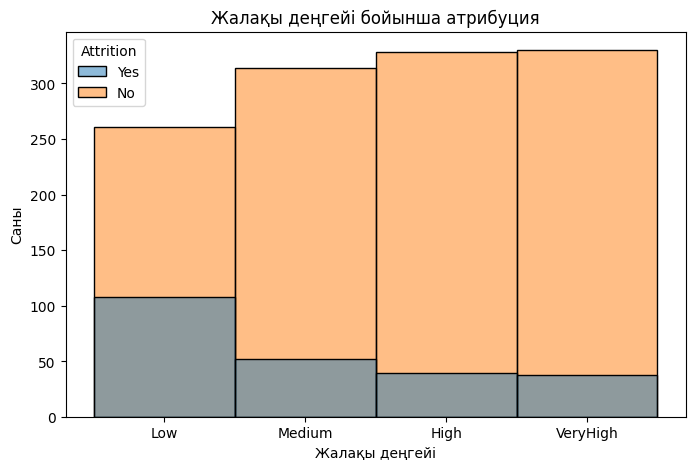

In [101]:
# TODO: MonthlyIncome бағанын 4 квантильге бөліңіз
# Кеңес: pd.qcut(df_clean['MonthlyIncome'], q=4, labels=['Low', 'Medium', 'High', 'VeryHigh'])
df_clean['IncomeLevel'] =pd.qcut(df_clean['MonthlyIncome'], q=4, labels=['Low', 'Medium', 'High', 'VeryHigh'])

print("Жалақы деңгейлері:")
print(df_clean['IncomeLevel'].value_counts())

# TODO: IncomeLevel бойынша Attrition countplot сызыңыз
plt.figure(figsize=(8, 5))

sns.histplot(x='IncomeLevel', hue='Attrition', data=df_clean)

plt.title('Жалақы деңгейі бойынша атрибуция')
plt.xlabel('Жалақы деңгейі')
plt.ylabel('Саны')
plt.show()

### 5.9-тапсырма. Өзара әрекеттесу белгілері (Interaction Features)

Екі бағанды комбинациялап жаңа белгілер жасаңыз.

In [ ]:
# TODO: Interaction features жасаңыз

# 1. Age * MonthlyIncome
df_clean['Age_Income'] =

# 2. Overtime мен DistanceFromHome комбинациясы
# Кеңес: OverTime бағанын алдымен сандық формаға ауыстырыңыз
df_clean['OverTime_num'] = df_clean['OverTime'].map({'Yes': 1, 'No': 0})

# TODO: OverTime_num * DistanceFromHome
df_clean['OT_Distance'] =

print("Interaction features:")
print(df_clean[['Age_Income', 'OT_Distance']].describe())

### 5.10-тапсырма. Қорытынды: дайын датасетті тексеру

Барлық озгертулерден кейінгі датасеттің соңғы жай-кұйін тексеріңіз.

In [ ]:
# TODO: Соңғы датасеттің ақпаратын шығарыңыз
print("Датасеттің соңғы күйі:")
print(f"Жолдар: {df_clean.shape[0]}")
print(f"Бағандар: {df_clean.shape[1]}")
print(f"\nБос мәндер: {df_clean.isnull().sum().sum()}")

# Сандық бағандар
num_cols = df_clean.select_dtypes(include='number').columns
print(f"\nСандық бағандар саны: {len(num_cols)}")

# Санаттық бағандар
cat_cols = df_clean.select_dtypes(include='object').columns
print(f"Санаттық бағандар саны: {len(cat_cols)}")
print(f"\nСанаттық бағандар: {cat_cols.tolist()}")

# TODO: Жаңа белгілердің тізімін шығарыңыз
new_features = ['AvgSatisfaction', 'AgeGroup', 'IncomePerYear', 'IncomeLevel',
                'Age_Income', 'OT_Distance', 'OverTime_num', 'Attrition_encoded']
print(f"\nЖаңа жасалған белгілер: {new_features}")
print("\nПрактикалық жұмыс аяқталды!")